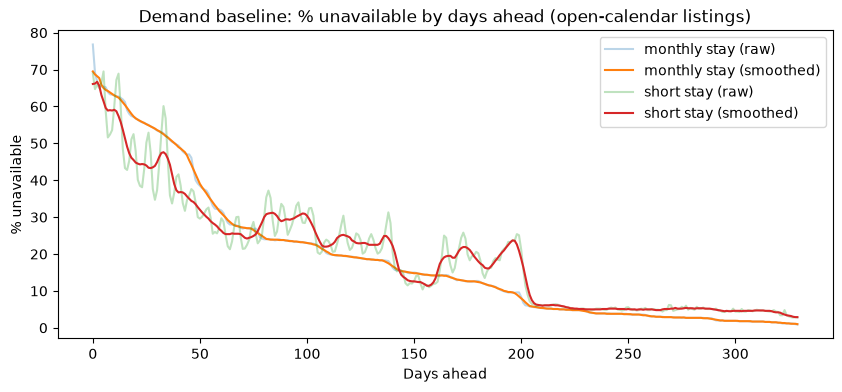

In [1]:
#Load and plot both curves
import duckdb
import pandas as pd
import matplotlib.pyplot as plt

curve = duckdb.sql(
    "SELECT * FROM read_parquet('../data/gold/nyc/demand_curve.parquet')"
).df()

fig, ax = plt.subplots(figsize=(10, 4))
for stay_type, group in curve.groupby("stay_type"):
    ax.plot(group["days_ahead"], group["pct_unavailable_raw"],
            alpha=0.3, label=f"{stay_type} (raw)")
    ax.plot(group["days_ahead"], group["pct_unavailable_smoothed"],
            label=f"{stay_type} (smoothed)")

ax.set_title("Demand baseline: % unavailable by days ahead (open-calendar listings)")
ax.set_xlabel("Days ahead")
ax.set_ylabel("% unavailable")
ax.legend()
plt.show()

In [2]:
# How many listings support each day?
print(curve.groupby("stay_type")["listings"].agg(["min", "median", "max"]))

                min   median    max
stay_type                          
monthly stay  10775  10775.0  10775
short stay     2652   2652.0   2652


In [3]:
#Spot-check specific days against Milestone 3D's numbers
checkpoints = curve[curve["days_ahead"].isin([0, 30, 60, 90, 180, 270, 300])]
print(checkpoints[["stay_type", "days_ahead", "listings", "pct_unavailable_smoothed"]]
      .sort_values(["stay_type", "days_ahead"]))

        stay_type  days_ahead  listings  pct_unavailable_smoothed
0    monthly stay           0     10775                      69.5
30   monthly stay          30     10775                      53.6
60   monthly stay          60     10775                      31.1
90   monthly stay          90     10775                      23.7
180  monthly stay         180     10775                      12.4
270  monthly stay         270     10775                       2.9
300  monthly stay         300     10775                       1.9
330    short stay           0      2652                      66.1
360    short stay          30      2652                      44.9
390    short stay          60      2652                      26.3
420    short stay          90      2652                      29.4
510    short stay         180      2652                      18.0
600    short stay         270      2652                       5.2
630    short stay         300      2652                       4.6
